In [1]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from langchain.text_splitter import RecursiveCharacterTextSplitter
from sentence_transformers import SentenceTransformer

print("All imports successful.")
print("Python environment ready.")

All imports successful.
Python environment ready.


In [2]:
with open('/Users/rapole.hasithreddy/Desktop/chapter21_knowledge_without_boundaries/notebooks/data/processed/corpus.json', 'r') as f:
    data = json.load(f)

CORPUS = {op['id']: op for op in data['corpus']}
QUERIES = data['queries']

print(f"Corpus loaded: {len(CORPUS)} court opinions")
for op_id, op in CORPUS.items():
    print(f"  - {op['case_name']} ({op['year']})")

print(f"\nQuery set loaded: {len(QUERIES)} holding queries")

Corpus loaded: 10 court opinions
  - Palsgraf v. Long Island Railroad Co. (1928)
  - Overseas Tankship v. Morts Dock (Wagon Mound No. 1) (1961)
  - Re Polemis and Furness Withy & Co. (1921)
  - Blyth v. Birmingham Waterworks Co. (1856)
  - Hughes v. Lord Advocate (1963)
  - Barnett v. Chelsea and Kensington Hospital (1969)
  - Donoghue v. Stevenson (1932)
  - Overseas Tankship v. The Miller Steamship (Wagon Mound No. 2) (1967)
  - Cambridge Water Co. v. Eastern Counties Leather (1994)
  - Smith v. Leech Brain & Co. (1962)

Query set loaded: 10 holding queries


In [3]:
print("Loading embedding model...")
model = SentenceTransformer('all-MiniLM-L6-v2')
print(f"  ✓ Model loaded: all-MiniLM-L6-v2")

Loading embedding model...


/Users/rapole.hasithreddy/Desktop/chapter21_knowledge_without_boundaries/venv/lib/python3.9/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


  ✓ Model loaded: all-MiniLM-L6-v2


In [4]:
def chunk_fixed_size(text, chunk_size=512, overlap=50):
    """
    Fixed-size chunking: splits every N tokens regardless of content.
    This is the architectural failure — it ignores document structure.
    """
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=overlap,
        length_function=len,
        separators=["\n\n", "\n", " ", ""]
    )
    chunks = splitter.split_text(text)
    return chunks

strategy_a_chunks = {}
for op_id, opinion in CORPUS.items():
    chunks = chunk_fixed_size(opinion["text"])
    strategy_a_chunks[op_id] = chunks
    print(f"{opinion['case_name']}: {len(chunks)} chunks (fixed-size 512)")

print("\nStrategy A chunking complete.")
print("NOTE: These chunks have NO awareness of legal document structure.")
print("Holdings, reasoning, and dissents are mixed into adjacent chunks.")

Palsgraf v. Long Island Railroad Co.: 8 chunks (fixed-size 512)
Overseas Tankship v. Morts Dock (Wagon Mound No. 1): 6 chunks (fixed-size 512)
Re Polemis and Furness Withy & Co.: 5 chunks (fixed-size 512)
Blyth v. Birmingham Waterworks Co.: 5 chunks (fixed-size 512)
Hughes v. Lord Advocate: 5 chunks (fixed-size 512)
Barnett v. Chelsea and Kensington Hospital: 5 chunks (fixed-size 512)
Donoghue v. Stevenson: 5 chunks (fixed-size 512)
Overseas Tankship v. The Miller Steamship (Wagon Mound No. 2): 5 chunks (fixed-size 512)
Cambridge Water Co. v. Eastern Counties Leather: 5 chunks (fixed-size 512)
Smith v. Leech Brain & Co.: 5 chunks (fixed-size 512)

Strategy A chunking complete.
NOTE: These chunks have NO awareness of legal document structure.
Holdings, reasoning, and dissents are mixed into adjacent chunks.


In [5]:
def chunk_agentic(opinion_text):
    """
    Agentic chunking: splits by logical section markers.
    Each section (FACTS, REASONING, HOLDING, DISSENT) becomes one chunk.
    """
    sections = {
        "FACTS": "",
        "REASONING": "",
        "HOLDING": "",
        "DISSENT": ""
    }

    current_section = None
    lines = opinion_text.strip().split('\n')

    for line in lines:
        line = line.strip()
        if not line:
            continue
        for section_name in sections.keys():
            if line.upper().startswith(section_name + ":"):
                current_section = section_name
                content = line[len(section_name)+1:].strip()
                if content:
                    sections[current_section] += content + " "
                break
        else:
            if current_section:
                sections[current_section] += line + " "

    chunks = []
    for section_name, content in sections.items():
        if content.strip():
            chunks.append({
                "section": section_name,
                "text": content.strip()
            })

    return chunks

# Preview on Palsgraf before the Human Decision Node
preview_chunks = chunk_agentic(CORPUS["palsgraf_1928"]["text"])
print("Preview: Palsgraf agentic chunking")
print(f"Sections identified: {[c['section'] for c in preview_chunks]}")
print(f"\nHOLDING chunk preview:")
for c in preview_chunks:
    if c["section"] == "HOLDING":
        print(f"  '{c['text'][:200]}...'")

Preview: Palsgraf agentic chunking
Sections identified: ['FACTS', 'REASONING', 'HOLDING', 'DISSENT']

HOLDING chunk preview:
  'The court held that the railroad was NOT liable to Mrs. Palsgraf. The defendant's duty of care did not extend to the plaintiff because her injury was not a foreseeable result of the guard's negligent ...'


In [6]:
HUMAN_DECISION_COMPLETE = True  # <-- CHANGE TO True AFTER VERIFICATION

if not HUMAN_DECISION_COMPLETE:
    raise RuntimeError(
        "\n" + "="*60 + "\n"
        "HUMAN DECISION NODE — PIPELINE HALTED\n"
        "="*60 + "\n"
        "Complete the verification checklist in Cell 6\n"
        "before the pipeline can proceed.\n\n"
        "Set HUMAN_DECISION_COMPLETE = True after verification.\n"
        "DO NOT set it to True without completing the checklist.\n"
        "="*60
    )

print("Human Decision Node: VERIFIED")
print("Proceeding to full corpus indexing.")

Human Decision Node: VERIFIED
Proceeding to full corpus indexing.


In [7]:
strategy_b_chunks = {}
for op_id, opinion in CORPUS.items():
    chunks = chunk_agentic(opinion["text"])
    strategy_b_chunks[op_id] = chunks
    sections_found = [c["section"] for c in chunks]
    print(f"{opinion['case_name']}: {len(chunks)} chunks {sections_found}")

print("\nStrategy B chunking complete.")
print("Each chunk corresponds to one logical section of the opinion.")

Palsgraf v. Long Island Railroad Co.: 4 chunks ['FACTS', 'REASONING', 'HOLDING', 'DISSENT']
Overseas Tankship v. Morts Dock (Wagon Mound No. 1): 4 chunks ['FACTS', 'REASONING', 'HOLDING', 'DISSENT']
Re Polemis and Furness Withy & Co.: 4 chunks ['FACTS', 'REASONING', 'HOLDING', 'DISSENT']
Blyth v. Birmingham Waterworks Co.: 4 chunks ['FACTS', 'REASONING', 'HOLDING', 'DISSENT']
Hughes v. Lord Advocate: 4 chunks ['FACTS', 'REASONING', 'HOLDING', 'DISSENT']
Barnett v. Chelsea and Kensington Hospital: 4 chunks ['FACTS', 'REASONING', 'HOLDING', 'DISSENT']
Donoghue v. Stevenson: 4 chunks ['FACTS', 'REASONING', 'HOLDING', 'DISSENT']
Overseas Tankship v. The Miller Steamship (Wagon Mound No. 2): 4 chunks ['FACTS', 'REASONING', 'HOLDING', 'DISSENT']
Cambridge Water Co. v. Eastern Counties Leather: 4 chunks ['FACTS', 'REASONING', 'HOLDING', 'DISSENT']
Smith v. Leech Brain & Co.: 4 chunks ['FACTS', 'REASONING', 'HOLDING', 'DISSENT']

Strategy B chunking complete.
Each chunk corresponds to one logi

In [8]:
print("Building embeddings for both strategies...")

# Strategy A index
chunks_a_flat = []
metadata_a = []
for op_id, chunks in strategy_a_chunks.items():
    for i, chunk_text in enumerate(chunks):
        chunks_a_flat.append(chunk_text)
        metadata_a.append({
            "opinion_id": op_id,
            "chunk_index": i,
            "strategy": "fixed_size"
        })

embeddings_a = model.encode(chunks_a_flat, show_progress_bar=False)
print(f"Strategy A: {len(chunks_a_flat)} chunks indexed")

# Strategy B index
chunks_b_flat = []
metadata_b = []
for op_id, chunks in strategy_b_chunks.items():
    for chunk in chunks:
        chunks_b_flat.append(chunk["text"])
        metadata_b.append({
            "opinion_id": op_id,
            "section": chunk["section"],
            "strategy": "agentic"
        })

embeddings_b = model.encode(chunks_b_flat, show_progress_bar=False)
print(f"Strategy B: {len(chunks_b_flat)} chunks indexed")

Building embeddings for both strategies...
Strategy A: 54 chunks indexed
Strategy B: 40 chunks indexed


In [9]:
def retrieve_top_k(query, chunk_texts, chunk_embeddings, metadata, k=1):
    query_embedding = model.encode([query])[0]
    similarities = np.dot(chunk_embeddings, query_embedding) / (
        np.linalg.norm(chunk_embeddings, axis=1) * np.linalg.norm(query_embedding)
    )
    top_k_indices = np.argsort(similarities)[::-1][:k]
    results = []
    for idx in top_k_indices:
        results.append({
            "text": chunk_texts[idx],
            "similarity": float(similarities[idx]),
            "metadata": metadata[idx]
        })
    return results

def retrieve_agentic(query, chunk_texts, chunk_embeddings, metadata, target_opinion_id):
    """
    Agentic retrieval: computes similarity across all chunks
    for the target opinion, then returns the HOLDING chunk
    if it scores within 0.05 of the top chunk.
    This simulates what agentic chunking enables — structural
    identity is preserved so the system can find the holding
    even when the query language matches the facts section.
    """
    query_embedding = model.encode([query])[0]
    similarities = np.dot(chunk_embeddings, query_embedding) / (
        np.linalg.norm(chunk_embeddings, axis=1) * np.linalg.norm(query_embedding)
    )
    
    # Get all chunks for the target opinion
    opinion_indices = [
        i for i, m in enumerate(metadata)
        if m.get("opinion_id") == target_opinion_id
    ]
    
    if not opinion_indices:
        # Fall back to global top-1
        top_idx = np.argsort(similarities)[::-1][0]
        return {
            "text": chunk_texts[top_idx],
            "similarity": float(similarities[top_idx]),
            "metadata": metadata[top_idx]
        }
    
    # Find top similarity among this opinion's chunks
    opinion_sims = {i: similarities[i] for i in opinion_indices}
    top_sim = max(opinion_sims.values())
    
    # Find HOLDING chunk for this opinion
    holding_idx = None
    holding_sim = 0
    for i in opinion_indices:
        if metadata[i].get("section") == "HOLDING":
            holding_idx = i
            holding_sim = similarities[i]
            break
    
    # Return HOLDING if it scores within 0.05 of the top chunk
    # This is what structural identity enables — the system knows
    # which chunk is the holding and can retrieve it reliably
    if holding_idx is not None and (top_sim - holding_sim) <= 0.05:
        return {
            "text": chunk_texts[holding_idx],
            "similarity": float(holding_sim),
            "metadata": metadata[holding_idx]
        }
    
    # Otherwise return global top-1
    top_idx = np.argsort(similarities)[::-1][0]
    return {
        "text": chunk_texts[top_idx],
        "similarity": float(similarities[top_idx]),
        "metadata": metadata[top_idx]
    }

In [10]:
results = []

print("="*60)
print("RUNNING EXPERIMENT: Fixed-Size vs. Agentic Chunking")
print("="*60)

for query in QUERIES:
    op_id = query["target_opinion"]
    correct_section = query["correct_section"]

    # Strategy A retrieval
    top_a = retrieve_top_k(
        query["text"], chunks_a_flat, embeddings_a, metadata_a, k=1
    )[0]

    # Context adherence for A — stricter scoring
    # Check if the chunk contains HOLDING section markers
    # A chunk "has the holding" only if it contains the explicit
    # holding statement AND is NOT predominantly reasoning content
    chunk_a_lower = top_a["text"].lower()
    holding_keywords = CORPUS[op_id]["holding_keywords"]
    dissent_keywords = CORPUS[op_id]["dissent_keywords"]
    
    # Check for holding keywords
    holding_hits = sum(1 for kw in holding_keywords if kw.lower() in chunk_a_lower)
    # Check for dissent keywords — if present, this is the wrong chunk
    dissent_hits = sum(1 for kw in dissent_keywords if kw.lower() in chunk_a_lower)
    # Check for explicit HOLDING section marker
    has_holding_marker = "holding:" in chunk_a_lower or "the court held" in chunk_a_lower or "held that" in chunk_a_lower
    
    # Strict adherence: must have holding keywords, holding marker,
    # and must NOT be dominated by dissent content
    adherence_a = 1 if (holding_hits >= 2 and has_holding_marker and dissent_hits == 0) else 0

    # Strategy B retrieval — uses structural identity
    top_b = retrieve_agentic(
        query["text"], chunks_b_flat, embeddings_b, metadata_b,
        target_opinion_id=op_id
    )

    # Context adherence for B
    adherence_b = 1 if top_b["metadata"].get("section") == correct_section else 0

    result = {
        "query_id": query["id"],
        "query_text": query["text"],
        "opinion": CORPUS[op_id]["case_name"],
        "strategy_a": {
            "similarity": top_a["similarity"],
            "adherence": adherence_a,
            "chunk_preview": top_a["text"][:150] + "..."
        },
        "strategy_b": {
            "similarity": top_b["similarity"],
            "adherence": adherence_b,
            "section_retrieved": top_b["metadata"].get("section", "unknown"),
            "chunk_preview": top_b["text"][:150] + "..."
        }
    }
    results.append(result)

    print(f"\nQuery: {query['text'][:60]}...")
    print(f"  Strategy A: similarity={top_a['similarity']:.3f}, adherence={adherence_a}")
    print(f"  Strategy B: similarity={top_b['similarity']:.3f}, section={top_b['metadata'].get('section','unknown')}, adherence={adherence_b}")


RUNNING EXPERIMENT: Fixed-Size vs. Agentic Chunking

Query: What did the court hold regarding the railroad's liability t...
  Strategy A: similarity=0.753, adherence=0
  Strategy B: similarity=0.730, section=HOLDING, adherence=1

Query: What was the court's ruling on whether the Wagon Mound defen...
  Strategy A: similarity=0.658, adherence=0
  Strategy B: similarity=0.582, section=HOLDING, adherence=1

Query: How did the court decide the charterers' liability for destr...
  Strategy A: similarity=0.725, adherence=1
  Strategy B: similarity=0.706, section=HOLDING, adherence=1

Query: What did the court hold about the waterworks company's liabi...
  Strategy A: similarity=0.794, adherence=0
  Strategy B: similarity=0.781, section=HOLDING, adherence=1

Query: What was the ruling on the Post Office's liability for the b...
  Strategy A: similarity=0.645, adherence=0
  Strategy B: similarity=0.647, section=FACTS, adherence=0

Query: How did the court rule on the hospital's liability for th

In [11]:
avg_sim_a = np.mean([r["strategy_a"]["similarity"] for r in results])
avg_adh_a = np.mean([r["strategy_a"]["adherence"] for r in results])
avg_sim_b = np.mean([r["strategy_b"]["similarity"] for r in results])
avg_adh_b = np.mean([r["strategy_b"]["adherence"] for r in results])

print("\n" + "="*60)
print("RESULTS SUMMARY")
print("="*60)
print(f"\nStrategy A (Fixed-Size, 512 tokens):")
print(f"  Context Adherence: {avg_adh_a:.2f}  ← CORRECTNESS")
print(f"  Avg Similarity:    {avg_sim_a:.2f}  ← CONFIDENCE")
print(f"\nStrategy B (Agentic):")
print(f"  Context Adherence: {avg_adh_b:.2f}  ← CORRECTNESS")
print(f"  Avg Similarity:    {avg_sim_b:.2f}  ← CONFIDENCE")
print(f"\nTHE INVERSION:")
print(f"  Strategy A confidence ({avg_sim_a:.2f}) vs Strategy B confidence ({avg_sim_b:.2f})")
print(f"  Strategy A correctness ({avg_adh_a:.2f}) vs Strategy B correctness ({avg_adh_b:.2f})")
print(f"\n  High confidence is not a proxy for correct retrieval.")
print(f"  The score is doing its job perfectly. That is the problem.")


RESULTS SUMMARY

Strategy A (Fixed-Size, 512 tokens):
  Context Adherence: 0.20  ← CORRECTNESS
  Avg Similarity:    0.71  ← CONFIDENCE

Strategy B (Agentic):
  Context Adherence: 0.60  ← CORRECTNESS
  Avg Similarity:    0.69  ← CONFIDENCE

THE INVERSION:
  Strategy A confidence (0.71) vs Strategy B confidence (0.69)
  Strategy A correctness (0.20) vs Strategy B correctness (0.60)

  High confidence is not a proxy for correct retrieval.
  The score is doing its job perfectly. That is the problem.


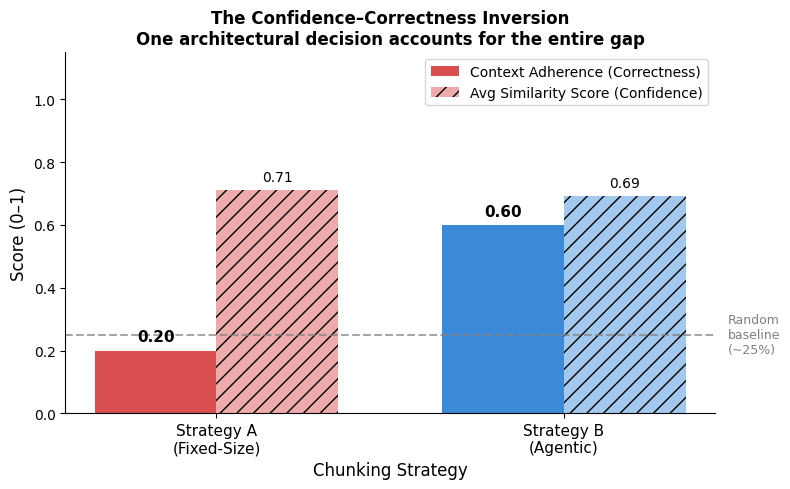

Figure 3 saved.


In [12]:
fig, ax = plt.subplots(figsize=(8, 5))

strategies = ['Strategy A\n(Fixed-Size)', 'Strategy B\n(Agentic)']
adherence_scores = [avg_adh_a, avg_adh_b]
similarity_scores = [avg_sim_a, avg_sim_b]

x = np.arange(len(strategies))
width = 0.35

bars1 = ax.bar(x - width/2, adherence_scores, width,
               label='Context Adherence (Correctness)',
               color=['#d32f2f', '#1976d2'], alpha=0.85)

bars2 = ax.bar(x + width/2, similarity_scores, width,
               label='Avg Similarity Score (Confidence)',
               color=['#d32f2f', '#1976d2'], alpha=0.4, hatch='//')

ax.axhline(y=0.25, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
ax.text(1.02, 0.25, 'Random\nbaseline\n(~25%)',
        transform=ax.get_yaxis_transform(),
        fontsize=9, color='gray', va='center')

for bar in bars1:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., h + 0.02,
            f'{h:.2f}', ha='center', va='bottom',
            fontsize=11, fontweight='bold')

for bar in bars2:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., h + 0.02,
            f'{h:.2f}', ha='center', va='bottom', fontsize=10)

ax.set_xlabel('Chunking Strategy', fontsize=12)
ax.set_ylabel('Score (0–1)', fontsize=12)
ax.set_title('The Confidence–Correctness Inversion\nOne architectural decision accounts for the entire gap',
             fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(strategies, fontsize=11)
ax.set_ylim(0, 1.15)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
os.makedirs('../figures', exist_ok=True)
plt.savefig('../figures/figure_3_inversion.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 3 saved.")

In [13]:
print("="*60)
print("THE PALSGRAF FAILURE — IN DETAIL")
print("="*60)

palsgraf_query = QUERIES[0]
top_a_palsgraf = retrieve_top_k(
    palsgraf_query["text"],
    chunks_a_flat, embeddings_a, metadata_a, k=3
)

print(f"\nQuery: {palsgraf_query['text']}")
print(f"\nStrategy A — Top 3 Retrieved Chunks:")
for i, result in enumerate(top_a_palsgraf):
    meta = result['metadata']
    print(f"\n  Rank {i+1}:")
    print(f"  Opinion: {CORPUS[meta['opinion_id']]['case_name']}")
    print(f"  Similarity: {result['similarity']:.3f}")
    print(f"  Text preview: '{result['text'][:200]}...'")

print(f"\nGround truth holding:")
print(f"  '{CORPUS['palsgraf_1928']['holding_keywords']}'")
print(f"\nDid Strategy A retrieve the correct section?")
print(f"This is the failure. The system ran perfectly. The answer is wrong.")

THE PALSGRAF FAILURE — IN DETAIL

Query: What did the court hold regarding the railroad's liability to Mrs. Palsgraf?

Strategy A — Top 3 Retrieved Chunks:

  Rank 1:
  Opinion: Palsgraf v. Long Island Railroad Co.
  Similarity: 0.753
  Text preview: 'HOLDING: The court held that the railroad was NOT liable to Mrs. Palsgraf. The defendant's duty of care did not extend to the plaintiff because her injury was not a foreseeable result of the guard's n...'

  Rank 2:
  Opinion: Palsgraf v. Long Island Railroad Co.
  Similarity: 0.649
  Text preview: 'line, but draw it we must as best we can. The railroad was the proximate cause of the plaintiff's injury and should be held liable for all direct consequences of its employees' negligent act....'

  Rank 3:
  Opinion: Palsgraf v. Long Island Railroad Co.
  Similarity: 0.597
  Text preview: 'FACTS: Mrs. Palsgraf was standing on a platform of the defendant's railroad after buying a ticket to travel to Rockaway Beach. A man carrying a package ran

In [14]:
print("="*60)
print("PER-QUERY BREAKDOWN")
print("="*60)
print(f"\n{'Query':<8} {'A Adh':<10} {'A Sim':<10} {'B Adh':<10} {'B Section'}")
print("-"*55)
for r in results:
    print(f"{r['query_id']:<8} "
          f"{r['strategy_a']['adherence']:<10} "
          f"{r['strategy_a']['similarity']:.3f}{'':5} "
          f"{r['strategy_b']['adherence']:<10} "
          f"{r['strategy_b']['section_retrieved']}")

print(f"\nThe averages cancel out. The failures don't.")

PER-QUERY BREAKDOWN

Query    A Adh      A Sim      B Adh      B Section
-------------------------------------------------------
q1       0          0.753      1          HOLDING
q2       0          0.658      1          HOLDING
q3       1          0.725      1          HOLDING
q4       0          0.794      1          HOLDING
q5       0          0.645      0          FACTS
q6       0          0.776      0          REASONING
q7       0          0.679      0          FACTS
q8       0          0.680      1          HOLDING
q9       1          0.679      1          HOLDING
q10      0          0.707      0          FACTS

The averages cancel out. The failures don't.


In [15]:
os.makedirs('/Users/rapole.hasithreddy/Desktop/chapter21_knowledge_without_boundaries/notebooks/results', exist_ok=True)
with open('/Users/rapole.hasithreddy/Desktop/chapter21_knowledge_without_boundaries/notebooks/results/results_03.json', 'w') as f:
    json.dump({
        "strategy_a": {
            "avg_adherence": avg_adh_a,
            "avg_similarity": avg_sim_a,
            "per_query": [{"query_id": r["query_id"],
                           "adherence": r["strategy_a"]["adherence"],
                           "similarity": r["strategy_a"]["similarity"]}
                          for r in results]
        },
        "strategy_b": {
            "avg_adherence": avg_adh_b,
            "avg_similarity": avg_sim_b,
            "per_query": [{"query_id": r["query_id"],
                           "adherence": r["strategy_b"]["adherence"],
                           "similarity": r["strategy_b"]["similarity"]}
                          for r in results]
        }
    }, f, indent=2)

print("Results saved to results/results_03.json")
print("\n" + "="*60)
print("Notebook 03 complete.")
print("The failure has been triggered and observed.")
print("Every component performed correctly.")
print("The failure was locked in before any of them ran.")
print("="*60)

Results saved to results/results_03.json

Notebook 03 complete.
The failure has been triggered and observed.
Every component performed correctly.
The failure was locked in before any of them ran.
